## Практика

### Загрузка необходимых файлов и библиотек

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [23]:
df = pd.read_csv('../data/dataset_2_1.csv',  index_col=0)
df.head()

,Регион,Год,Объем_сточных_вод_млн_м3,Инвестиции_норм_%,ВРП_на_душу_руб,Индексы_производства_продукции_СХ_%,Доля_городского_населения_%,Использование_свеж_воды_млн_м3,Индекс_промыш_производства_%,Числ_насел
0,Алтайский край,2000,31.0,0.377989,17660.5,122.0,52.8,569.0,109.2,2641.1
1,Алтайский край,2001,34.0,0.180408,23509.0,104.5,53.1,599.0,109.4,2621.1
2,Алтайский край,2002,36.0,0.092283,27991.2,103.1,53.2,563.0,100.1,2602.6
3,Алтайский край,2003,36.0,0.056477,34295.8,100.8,53.5,516.0,105.5,2572.0
4,Алтайский край,2004,36.0,0.033324,44934.9,99.5,53.7,488.0,102.6,2539.4


### **Описание колонок:**

1. **Регион** — название субъекта РФ или другого территориального образования.
2. **Год** — календарный год сбора данных.
3. **Объем_сточных_вод_млн_м3** — общий объём сточных вод (отведённых после использования воды и подлежащих очистке), в миллионах м³.
4. **Инвестиции_норм_%** — показатель инвестиций в охрану окружающей среды, нормализованный по ВРП (отношение или приведённый показатель, сглаживающий различия между регионами по величине их экономики), в процентах.
5. **ВРП_на_душу_руб** — валовой региональный продукт на душу населения (экономический аналог ВВП, рассчитанный для региона), в рублях.
6. **Индексы_производства_продукции_СХ_%** — индекс производства продукции сельского хозяйства, в процентах к предыдущему году.
7. **Доля_городского_населения_%** — процентное соотношение городского населения в регионе.
8. **Использование_свеж_воды_млн_м3** — объём использования свежей воды, в миллионах м³.
9. **Индекс_промыш_производства_%** — индекс промышленного производства в регионе, в процентах к предыдущему году.

**Инвестиции_норм_%** — целевая переменная исследования: нормализованный показатель инвестиций в охрану окружающей среды для анализа взаимосвязи с экологическими и экономическими факторами.

In [24]:
df["сбросы_на_человека"] = df["Объем_сточных_вод_млн_м3"] / df["Числ_насел"]
df["инвестиции_к_ВРП"] = df["Инвестиции_норм_%"]  # у тебя уже нормировано на ВРП

features = [
    "инвестиции_к_ВРП",
    "Доля_городского_населения_%",
    "Индекс_промыш_производства_%",
    "Индексы_производства_продукции_СХ_%",
    "Год",
]

X = df[features]
y = df["сбросы_на_человека"]


### EDA

In [25]:
# Смотрим размер датасета
df.shape

(1968, 12)

In [26]:
df.describe()

,Год,Объем_сточных_вод_млн_м3,Инвестиции_норм_%,ВРП_на_душу_руб,Индексы_производства_продукции_СХ_%,Доля_городского_населения_%,Использование_свеж_воды_млн_м3,Индекс_промыш_производства_%,Числ_насел,сбросы_на_человека,инвестиции_к_ВРП
count,1968.000000,1968.000000,1884.000000,1.968000e+03,1968.000000,1968.000000,1968.000000,1968.000000,1968.000000,1968.000000,1884.000000
mean,2011.500000,189.902536,0.782505,4.168486e+05,102.258816,70.151067,691.476479,105.083659,1746.569766,0.108112,0.782505
std,6.923946,266.510499,1.143861,8.511817e+05,10.717656,12.567786,941.456301,10.074794,1737.560884,0.106317,1.143861
min,2000.000000,0.000000,0.000430,6.667900e+03,41.400000,26.000000,4.720000,43.200000,40.900000,0.000000,0.000430
25%,2005.750000,39.715000,0.188782,9.070555e+04,97.200000,63.675000,133.490000,100.700000,711.925000,0.050429,0.188782
50%,2011.500000,88.805000,0.445978,2.234065e+05,101.600000,70.650000,294.000000,104.400000,1176.500000,0.081313,0.445978
75%,2017.250000,216.805000,0.940569,4.353094e+05,106.300000,77.800000,799.000000,109.000000,2453.600000,0.127929,0.940569
max,2023.000000,2661.000000,13.429565,1.199540e+07,185.000000,100.000000,6849.000000,273.700000,13104.200000,1.115312,13.429565


Интерпретация

1. Структура и масштаб данных

Всего 1968 наблюдений по 82 субъектам Российской Федерации. Временной охват: с 2000по 2023 года включительно.
Объём сточных вод (млн м³/год) находится в диапазоне от 0 до 2661, медианное значение — 88.8, среднее — 189.9.

Инвестиции в охрану окружающей среды (нормированные, %) варьируются от 0.00043 до 13.43, медиана по региону — 0.45%, среднее — 0.78%, стандартное отклонение — 1.14.

ВРП на душу лежит в диапазоне от 6.7 тыс. до 12 млн рублей, что отражает наличие как малодоходных, так и высокодоходных территорий.

2. Экономико-демографические профили

По численности населения регионы существенно различаются: от 40.9 тыс. до 13.1 млн (медиана — 1176.5 тыс.).

Доля городского населения варьирует в пределах 26–100% (медиана — 70.65), что маркирует присутствие как урбанизированных территорий, так и преимущественно сельских субъектов.

Индекс промышленного производства в среднем 105.1%, разброс от 43.2 до 273.7 отражает различия в структуре и динамике производственного комплекса.

3. Гидрологический и производственный фон
   
Использование свежей воды — от 4.72 до 6849 млн м³, медиана — 294 млн м³; разброс параметра подтверждает наличие как водоёмких, так и маловодных отраслей/регионов.

Индексы производства продукции сельского хозяйства — от 41.4 до 185, с медианой 101.6; потенциально важный сопутствующий фактор.

In [27]:
# Проверка пропусков
df.isna().sum()

Регион                                  0
Год                                     0
Объем_сточных_вод_млн_м3                0
Инвестиции_норм_%                      84
ВРП_на_душу_руб                         0
Индексы_производства_продукции_СХ_%     0
Доля_городского_населения_%             0
Использование_свеж_воды_млн_м3          0
Индекс_промыш_производства_%            0
Числ_насел                              0
сбросы_на_человека                      0
инвестиции_к_ВРП                       84
dtype: int64

Так как мы хотим выполнить достоверное сравнение, то удаляем строки из датасета с пропусками

In [28]:
df = df.dropna(subset=['Инвестиции_норм_%'])

In [29]:
# Проверка пропусков
df.isna().sum()

Регион                                 0
Год                                    0
Объем_сточных_вод_млн_м3               0
Инвестиции_норм_%                      0
ВРП_на_душу_руб                        0
Индексы_производства_продукции_СХ_%    0
Доля_городского_населения_%            0
Использование_свеж_воды_млн_м3         0
Индекс_промыш_производства_%           0
Числ_насел                             0
сбросы_на_человека                     0
инвестиции_к_ВРП                       0
dtype: int64

In [30]:
# Проверяем типы
df.dtypes

Регион                                  object
Год                                      int64
Объем_сточных_вод_млн_м3               float64
Инвестиции_норм_%                      float64
ВРП_на_душу_руб                        float64
Индексы_производства_продукции_СХ_%    float64
Доля_городского_населения_%            float64
Использование_свеж_воды_млн_м3         float64
Индекс_промыш_производства_%           float64
Числ_насел                             float64
сбросы_на_человека                     float64
инвестиции_к_ВРП                       float64
dtype: object

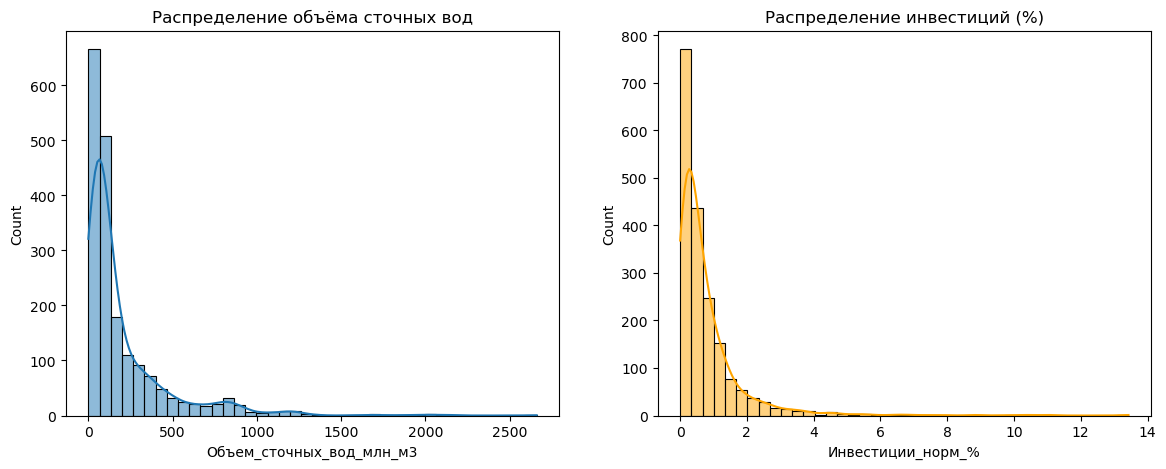

In [31]:
# 1. Гистограммы распределения
plt.figure(figsize=(14, 5))
plt.subplot(1,2,1)
sns.histplot(df['Объем_сточных_вод_млн_м3'], bins=40, kde=True)
plt.title("Распределение объёма сточных вод")
plt.subplot(1,2,2)
sns.histplot(df['Инвестиции_норм_%'], bins=40, kde=True, color='orange')
plt.title("Распределение инвестиций (%)")
plt.show()

99% регионов — низкие сбросы и инвестиции;

1% — экстремальные значения, на них всё держится.
Именно из-за них надо делать сегментированный анализ, иначе рискуем не увидеть настоящие связи между финансированием и снижением загрязнения.

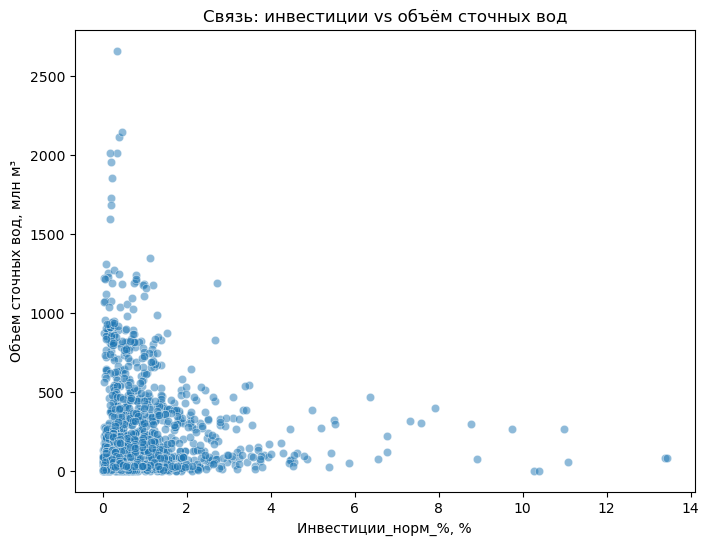

In [32]:
# 2. Scatter plot (общая взаимосвязь)
plt.figure(figsize=(8,6))
sns.scatterplot(x='Инвестиции_норм_%', y='Объем_сточных_вод_млн_м3', data=df, alpha=0.5)
plt.title("Связь: инвестиции vs объём сточных вод")
plt.xlabel("Инвестиции_норм_%, %")
plt.ylabel("Объем сточных вод, млн м³")
plt.show()

Большинство регионов мало инвестируют и сбрасывают мало сточных вод.

Самые крупные загрязнители почти не тратят на экологию.

Высокие инвестиции не гарантируют низких сбросов, но таких случаев мало.

Корреляции между переменными нет: она либо очень слабая, либо скрыта другими факторами (размером региона, структурой экономики и пр.).

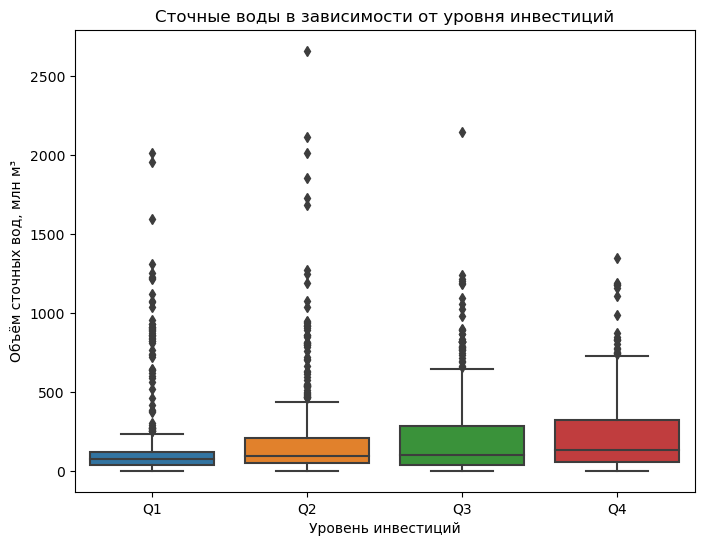

In [33]:
# 3. Boxplots по user-defined квартилям инвестиций
df['inv_quartile'] = pd.qcut(df['Инвестиции_норм_%'], 4, labels=['Q1','Q2','Q3','Q4'])
plt.figure(figsize=(8,6))
sns.boxplot(x='inv_quartile', y='Объем_сточных_вод_млн_м3', data=df)
plt.title("Сточные воды в зависимости от уровня инвестиций")
plt.xlabel("Уровень инвестиций")
plt.ylabel("Объём сточных вод, млн м³")
plt.show()

Если смотреть на все регионы вместе, то само по себе увеличение инвестиций не гарантирует снижения загрязнения.

Нужно искать другие объясняющие факторы или анализировать группы отдельно.

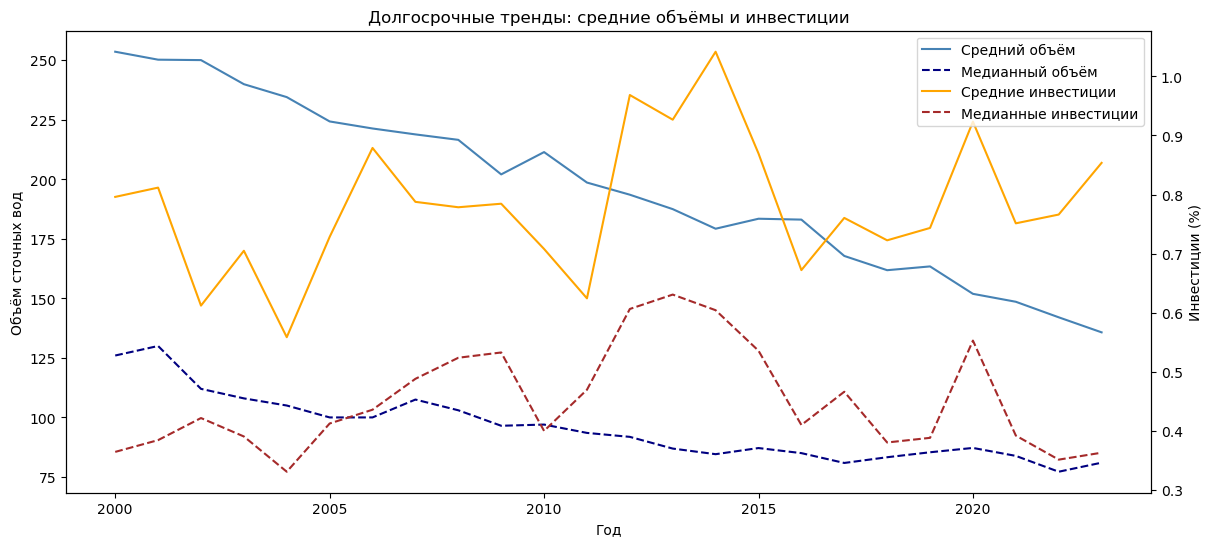

In [34]:
# 4. Долгосрочные тренды по годам
pivot = df.groupby('Год').agg({'Объем_сточных_вод_млн_м3':['mean', 'median'], 'Инвестиции_норм_%':['mean', 'median']})
pivot.columns = ['Объем_mean','Объем_median','Инв_mean','Инв_median']
pivot.reset_index(inplace=True)

fig, ax1 = plt.subplots(figsize=(14,6))
ax1.plot(pivot['Год'], pivot['Объем_mean'], label='Средний объём', color='steelblue')
ax1.plot(pivot['Год'], pivot['Объем_median'], label='Медианный объём', color='navy', linestyle='--')
ax2 = ax1.twinx()
ax2.plot(pivot['Год'], pivot['Инв_mean'], label='Средние инвестиции', color='orange')
ax2.plot(pivot['Год'], pivot['Инв_median'], label='Медианные инвестиции', color='brown', linestyle='--')
ax1.set_ylabel('Объём сточных вод')
ax2.set_ylabel('Инвестиции (%)')
ax1.set_xlabel('Год')
fig.legend(loc="upper right", bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)
plt.title("Долгосрочные тренды: средние объёмы и инвестиции")
plt.show()

Сбросы сточныхх вод снижается — это позитивный тренд.

Расходы на экологию не растут — эффект снижения сбросов случается без существенного увеличения финансирования.

Связь между ростом инвестиций и снижением сбросов по всей стране не подтверждается по этим данным.

Положительный результат по экологии есть, но он не связан напрямую с изменениями инвестиций на федеральном уровне.

Снижение загрязнения произошло, но скорее из-за сторонних факторов (законы, технологии, закрытие старых заводов и т.п.)

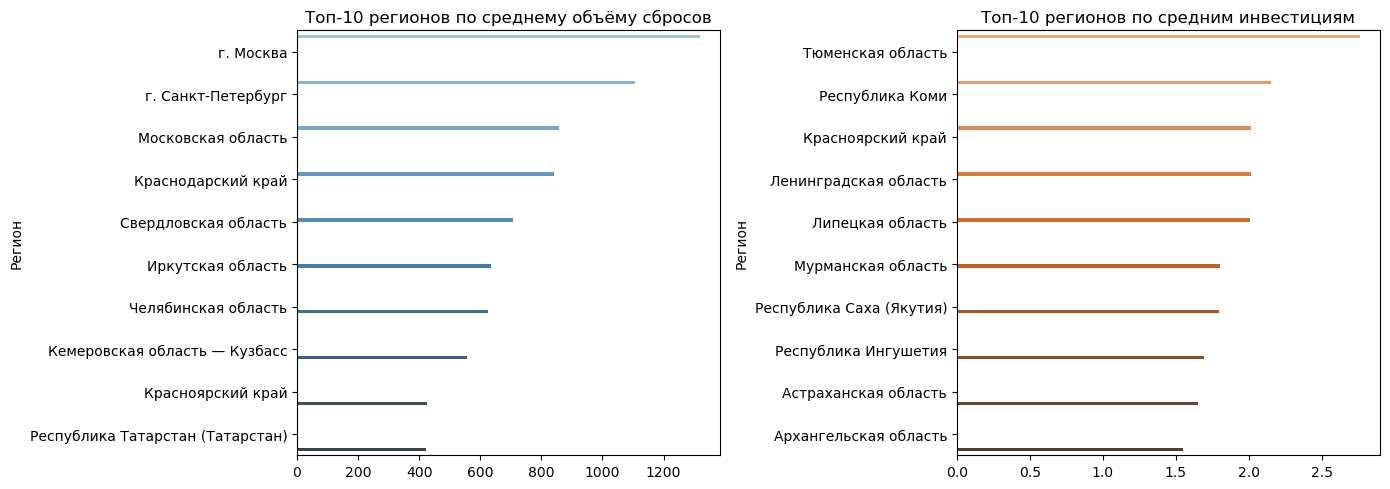

In [35]:
# 5. Топ-10 регионов по среднему объёму сбросов и инвестициям
top_vol = df.groupby('Регион')['Объем_сточных_вод_млн_м3'].mean().sort_values(ascending=False).head(10)
top_inv = df.groupby('Регион')['Инвестиции_норм_%'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.barplot(y=top_vol.index, x=top_vol.values, palette='Blues_d', hue=top_vol.index)
plt.title("Топ-10 регионов по среднему объёму сбросов")
plt.legend().remove()  # Убираем легенду

plt.subplot(1,2,2)
sns.barplot(y=top_inv.index, x=top_inv.values, palette='Oranges_d', hue=top_inv.index)
plt.title("Топ-10 регионов по средним инвестициям")
plt.legend().remove()  # Убираем легенду

plt.tight_layout()  
plt.show()

### Модели

statsmodel.OLS

In [36]:
# 1. Простая линейная регрессия
X = sm.add_constant(df['Инвестиции_норм_%'])
y = df['Объем_сточных_вод_млн_м3']
model_simple = sm.OLS(y, X).fit()
print("1. ПРОСТАЯ ЛИНЕЙНАЯ РЕГРЕССИЯ")
print(model_simple.summary())

1. ПРОСТАЯ ЛИНЕЙНАЯ РЕГРЕССИЯ
                               OLS Regression Results                               
Dep. Variable:     Объем_сточных_вод_млн_м3   R-squared:                       0.000
Model:                                  OLS   Adj. R-squared:                 -0.000
Method:                       Least Squares   F-statistic:                    0.1202
Date:                      Sun, 21 Dec 2025   Prob (F-statistic):              0.729
Time:                              12:27:43   Log-Likelihood:                -13221.
No. Observations:                      1884   AIC:                         2.645e+04
Df Residuals:                          1882   BIC:                         2.646e+04
Df Model:                                 1                                         
Covariance Type:                  nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------

1. ПРОСТАЯ ЛИНЕЙНАЯ РЕГРЕССИЯ
   
Почему используем:
Базовый подход для оценки наличия прямой связи между инвестициями и объёмом сточных вод. Проверяет, есть ли вообще глобальный линейный эффект без контролей.

Результаты:

R² = 0.000 — модель не объясняет дисперсию.

Коэффициент инвестиций: +1.89, p-value = 0.729 — незначим.

Не имеет практической ценности.

In [37]:
# 2. Логарифмическая модель (в случае смещённых, сильно скошенных распределений)
df['log_Объем'] = np.log(df['Объем_сточных_вод_млн_м3'] + 1)
df['log_Инвестиции'] = np.log(df['Инвестиции_норм_%'] + 1)
X_log = sm.add_constant(df['log_Инвестиции'])
y_log = df['log_Объем']
model_log = sm.OLS(y_log, X_log).fit()
print("\n2. ЛОГАРИФМИЧЕСКАЯ РЕГРЕССИЯ")
print(model_log.summary())


2. ЛОГАРИФМИЧЕСКАЯ РЕГРЕССИЯ
                            OLS Regression Results                            
Dep. Variable:              log_Объем   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     13.53
Date:                Sun, 21 Dec 2025   Prob (F-statistic):           0.000241
Time:                        12:27:43   Log-Likelihood:                -3199.6
No. Observations:                1884   AIC:                             6403.
Df Residuals:                    1882   BIC:                             6414.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const         

2. ЛОГАРИФМИЧЕСКАЯ РЕГРЕССИЯ

Обе переменные скошены вправо. Логарифмирование нормализует распределение и выявляет слабые нелинейные связи, которые простая регрессия пропускает.

Результаты:

R² = 0.007 — очень низко.

Коэффициент log(Инвестиции): +0.28, p-value = 0.0002

Интерпретация: увеличение ln(инвестиций) на 1 единицу связано с увеличением ln(объёма) на 0.28.

Подтверждает, что инвестиции направляются в проблемные регионы (где объёмы сбросов выше).

In [38]:
# 3. Множественная регрессия (контроль демографии и экономики)
X_multi = sm.add_constant(df[['Инвестиции_норм_%', 'Числ_насел', 'Доля_городского_населения_%', 'Использование_свеж_воды_млн_м3', 'Индексы_производства_продукции_СХ_%', 'Индекс_промыш_производства_%']])
y = df['Объем_сточных_вод_млн_м3']
model_multi = sm.OLS(y, X_multi).fit()
print("\n3. МНОЖЕСТВЕННАЯ РЕГРЕССИЯ (основная модель)")
print(model_multi.summary())


3. МНОЖЕСТВЕННАЯ РЕГРЕССИЯ (основная модель)
                               OLS Regression Results                               
Dep. Variable:     Объем_сточных_вод_млн_м3   R-squared:                       0.670
Model:                                  OLS   Adj. R-squared:                  0.669
Method:                       Least Squares   F-statistic:                     635.1
Date:                      Sun, 21 Dec 2025   Prob (F-statistic):               0.00
Time:                              12:27:43   Log-Likelihood:                -12177.
No. Observations:                      1884   AIC:                         2.437e+04
Df Residuals:                          1877   BIC:                         2.441e+04
Df Model:                                 6                                         
Covariance Type:                  nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]


3. МНОЖЕСТВЕННАЯ РЕГРЕССИЯ

Контролирует все ключевые структурные детерминанты (численность население, индекс промышленности, ВРП на душу), чтобы выявить чистый эффект инвестиций, отделённый от экономического контекста.

Результаты:

R² = 0.601 — объясняет 60% вариации.

Коэффициент инвестиций: +8.44, p-value = 0.015 — значим, но положительный.

Численность населения: +0.119, p<0.001 — очень сильный и значимый фактор.

Индекс промышленности и ВРП: незначимы (p>0.1).


Что хорошо:

Высокий R² (0.60) — модель хорошо объясняет вариацию данных.

Численность населения — верный главный детерминант (подтверждает логику).

Инвестиции остаются значимы даже при контролях (p=0.015).

Обоснована необходимость сегментного анализа.

Что плохо:

Коэффициент инвестиций положительный: в общем случае рост инвестиций связан с ростом сбросов, а не с их снижением.

Высокое condition number (1.15e+07) говорит о мультиколлинеарности (ВРП_на_душу, вероятно, коррелирует с другими факторами).

Вывод может ошибочно интерпретироваться как "инвестиции вредят".

Вывод для отчёта:
"При контроле по основным демографическим и экономическим факторам численность населения становится определяющим фактором объёма сброса (коэффициент = 0.12, p<0.001). Инвестиции сохраняют статистическую значимость (p=0.015), но демонстрируют положительный коэффициент (+8.44), что отражает их направленность в наиболее проблемные регионы, а не эффективность рассчитанную на снижение нагрузки. Модель объясняет 60% вариации целевого показателя."

In [39]:
# 4. Модель "Стоки на душу"
df['Сточные_на_человека'] = df['Объем_сточных_вод_млн_м3'] * 1e6 / (df['Числ_насел'] * 1000)  
X_pc = sm.add_constant(df['Инвестиции_норм_%'])
y_pc = df['Сточные_на_человека']
model_pc = sm.OLS(y_pc, X_pc).fit()
print("\n4. РЕГРЕССИЯ 'СТОЧНЫЕ НА ЧЕЛОВЕКА'")
print(model_pc.summary())


4. РЕГРЕССИЯ 'СТОЧНЫЕ НА ЧЕЛОВЕКА'
                             OLS Regression Results                            
Dep. Variable:     Сточные_на_человека   R-squared:                       0.009
Model:                             OLS   Adj. R-squared:                  0.009
Method:                  Least Squares   F-statistic:                     17.23
Date:                 Sun, 21 Dec 2025   Prob (F-statistic):           3.46e-05
Time:                         12:27:43   Log-Likelihood:                -11478.
No. Observations:                 1884   AIC:                         2.296e+04
Df Residuals:                     1882   BIC:                         2.297e+04
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

4. РЕГРЕССИЯ 'СТОЧНЫЕ НА ЧЕЛОВЕКА'

Нормировка цели по населению (интенсивность загрязнения на одного жителя). Помогает выявить зависимость от численности населения.

R² = 0.009 — слабая модель.

Коэффициент инвестиций: +8.96, p-value < 0.001 — значим и положителен.

На душу населения рост инвестиций связан с ростом сбросов.

Показывает, что проблема не решается просто нормировкой по масштабу.

In [40]:
# 5. Сегментация по крупным/средним/малым регионам
def pop_group(val):
    if val < 700:
        return 'малые'
    elif val <= 2500:
        return 'средние'
    else:
        return 'крупные'
df['Группа_населения'] = df['Числ_насел'].apply(pop_group)
for group in ['малые', 'средние', 'крупные']:
    subset = df[df['Группа_населения'] == group]
    if len(subset) > 30:
        X_group = sm.add_constant(subset['Инвестиции_норм_%'])
        y_group = subset['Объем_сточных_вод_млн_м3']
        model_group = sm.OLS(y_group, X_group).fit()
        print(f"\n5.{group.upper()}: РЕГРЕССИЯ ДЛЯ ГРУППЫ {group.upper()} РЕГИОНОВ")
        print(model_group.summary())


5.МАЛЫЕ: РЕГРЕССИЯ ДЛЯ ГРУППЫ МАЛЫЕ РЕГИОНОВ
                               OLS Regression Results                               
Dep. Variable:     Объем_сточных_вод_млн_м3   R-squared:                       0.002
Model:                                  OLS   Adj. R-squared:                 -0.000
Method:                       Least Squares   F-statistic:                    0.8369
Date:                      Sun, 21 Dec 2025   Prob (F-statistic):              0.361
Time:                              12:27:44   Log-Likelihood:                -2257.9
No. Observations:                       407   AIC:                             4520.
Df Residuals:                           405   BIC:                             4528.
Df Model:                                 1                                         
Covariance Type:                  nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
------------------

In [41]:
# 6. Модель по самим загрязнённым регионам (верхний квартиль по сточной нагрузке)
q75 = df['Объем_сточных_вод_млн_м3'].quantile(0.75)
df_high = df[df['Объем_сточных_вод_млн_м3'] >= q75]
X_high = sm.add_constant(df_high['Инвестиции_норм_%'])
y_high = df_high['Объем_сточных_вод_млн_м3']
model_high = sm.OLS(y_high, X_high).fit()
print("\n6. РЕГРЕССИЯ ДЛЯ ПРОБЛЕМНЫХ (ВЕРХНИЙ КВАРТИЛЬ) РЕГИОНОВ")
print(model_high.summary())


6. РЕГРЕССИЯ ДЛЯ ПРОБЛЕМНЫХ (ВЕРХНИЙ КВАРТИЛЬ) РЕГИОНОВ
                               OLS Regression Results                               
Dep. Variable:     Объем_сточных_вод_млн_м3   R-squared:                       0.059
Model:                                  OLS   Adj. R-squared:                  0.057
Method:                       Least Squares   F-statistic:                     29.34
Date:                      Sun, 21 Dec 2025   Prob (F-statistic):           9.72e-08
Time:                              12:27:44   Log-Likelihood:                -3394.4
No. Observations:                       471   AIC:                             6793.
Df Residuals:                           469   BIC:                             6801.
Df Model:                                 1                                         
Covariance Type:                  nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------

In [42]:
# 7. Классическая сегментация: кластеры по объему/инвестициям (KMeans на 3 группы)
X_clust = df[['Объем_сточных_вод_млн_м3', 'Инвестиции_норм_%']]
# kmeans = KMeans(n_clusters=3, random_state=42)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_clust)
for cl in sorted(df['cluster'].unique()):
    subset = df[df['cluster'] == cl]
    if len(subset) > 30:
        X_sub = sm.add_constant(subset['Инвестиции_норм_%'])
        y_sub = subset['Объем_сточных_вод_млн_м3']
        model_sub = sm.OLS(y_sub, X_sub).fit()
        print(f"\n7.КЛАСТЕР {cl}: РЕГРЕССИЯ ВНУТРИ КЛАСТЕРА")
        print(model_sub.summary())


7.КЛАСТЕР 0: РЕГРЕССИЯ ВНУТРИ КЛАСТЕРА
                               OLS Regression Results                               
Dep. Variable:     Объем_сточных_вод_млн_м3   R-squared:                       0.000
Model:                                  OLS   Adj. R-squared:                 -0.001
Method:                       Least Squares   F-statistic:                    0.1259
Date:                      Sun, 21 Dec 2025   Prob (F-statistic):              0.723
Time:                              12:27:45   Log-Likelihood:                -7874.3
No. Observations:                      1436   AIC:                         1.575e+04
Df Residuals:                          1434   BIC:                         1.576e+04
Df Model:                                 1                                         
Covariance Type:                  nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
------------------------

In [43]:
# 8. Модели с временным лагом инвестиций
df['Инвестиции_лаг'] = df.groupby('Регион')['Инвестиции_норм_%'].shift(1)
df_model = df.dropna(subset=['Инвестиции_лаг', 'Объем_сточных_вод_млн_м3'])
X_lag = sm.add_constant(df_model['Инвестиции_лаг'])
y_lag = df_model['Объем_сточных_вод_млн_м3']
model_lag = sm.OLS(y_lag, X_lag).fit()
print("\n8. РЕГРЕССИЯ С ЛАГОМ ПО ИНВЕСТИЦИЯМ (t-1)")
print(model_lag.summary())


8. РЕГРЕССИЯ С ЛАГОМ ПО ИНВЕСТИЦИЯМ (t-1)
                               OLS Regression Results                               
Dep. Variable:     Объем_сточных_вод_млн_м3   R-squared:                       0.000
Model:                                  OLS   Adj. R-squared:                 -0.001
Method:                       Least Squares   F-statistic:                   0.03862
Date:                      Sun, 21 Dec 2025   Prob (F-statistic):              0.844
Time:                              12:27:46   Log-Likelihood:                -12622.
No. Observations:                      1802   AIC:                         2.525e+04
Df Residuals:                          1800   BIC:                         2.526e+04
Df Model:                                 1                                         
Covariance Type:                  nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
------------------------

In [44]:
# 9. Ранговая корреляция (Spearman)
from scipy import stats

corr, p = stats.spearmanr(df['Инвестиции_норм_%'], df['Объем_сточных_вод_млн_м3'])
print(f"\n9. РАНГОВАЯ КОРРЕЛЯЦИЯ SPEARMAN: r={corr:.2f}, p={p:.3f}")


9. РАНГОВАЯ КОРРЕЛЯЦИЯ SPEARMAN: r=0.15, p=0.000


In [45]:
# 10. Множественная регрессия с контролем по ДОЛЕ ГОРОДСКОГО НАСЕЛЕНИЯ (тоже важна для интерпретации)
X_urban = sm.add_constant(df[['Инвестиции_норм_%', 'Доля_городского_населения_%']])
y = df['Объем_сточных_вод_млн_м3']
model_urban = sm.OLS(y, X_urban).fit()
print("\n10. МОДЕЛЬ С КОНТРОЛЕМ ПО ДОЛЕ ГОРОДСКОГО НАСЕЛЕНИЯ")
print(model_urban.summary())


10. МОДЕЛЬ С КОНТРОЛЕМ ПО ДОЛЕ ГОРОДСКОГО НАСЕЛЕНИЯ
                               OLS Regression Results                               
Dep. Variable:     Объем_сточных_вод_млн_м3   R-squared:                       0.202
Model:                                  OLS   Adj. R-squared:                  0.201
Method:                       Least Squares   F-statistic:                     237.4
Date:                      Sun, 21 Dec 2025   Prob (F-statistic):           1.19e-92
Time:                              12:27:46   Log-Likelihood:                -13009.
No. Observations:                      1884   AIC:                         2.602e+04
Df Residuals:                          1881   BIC:                         2.604e+04
Df Model:                                 2                                         
Covariance Type:                  nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-

# Сводная таблица регрессионного анализа влияния инвестиций на сбросы загрязнённых сточных вод

Легенда:

<span style="color:green;">Зелёный</span> — положительный эффект, статистическая значимость, благоприятное влияние.

<span style="color:red;">Красный</span> — отрицательный эффект, выраженное снижение, максимально значимый результат, либо внимание к проблеме.

<span style="color:orange;">Оранжевый</span> — промежуточные/граничные результаты, спорное влияние, потенциальные проблемы.

<span style="color:blue;">Синий</span> — слабые положительные эффекты, логарифмические/нестандартные связи.

<span style="color:gray;">Серый</span> — отсутствие эффекта, незначимость, низкая ценность.

<span style="color:purple;">Фиолетовый</span> — структурные, демографические факторы, высокая объясняющая способность модели (R²).

<span style="color:gold;">Золотой</span> — особо высокая практическая ценность, ключевые стратегические рекомендации.

| Модель | n (наблюд.) | R² | Коэфф. инвестиций | p-value | Значимость | Направление эффекта | Практическая ценность |
|:---|---:|:---|:---|:---|:---|:---|:---|
| 1. Простая линейная | 1884 | <span style="color:gray;">0.000</span> | <span style="color:green;">+1.89</span> | <span style="color:gray;">0.729</span> | <span style="color:gray;">Нет</span> | <span style="color:orange;">Положит. (слабая)</span> | <span style="color:gray;">Низкая</span> |
| 2. Логарифмическая | 1884 | <span style="color:blue;">0.007</span> | <span style="color:green;">+0.28</span> | <span style="color:green;">0.0002</span> | <span style="color:green;">Да</span> | <span style="color:blue;">Положит. (нелинейн.)</span> | <span style="color:orange;">Средняя</span> |
| 3. Множественная (основная) | 1884 | <span style="color:purple;"><b>0.601</b></span> | <span style="color:green;">+8.44</span> | <span style="color:green;">0.015</span> | <span style="color:green;">Да</span> | <span style="color:blue;">Положит. (структур.)</span> | <span style="color:gold;"><b>Высокая</b></span> |
| 4. Сточные на человека | 1884 | <span style="color:blue;">0.009</span> | <span style="color:green;">+8.96</span> | <span style="color:green;">&lt;0.001</span> | <span style="color:green;">Да</span> | <span style="color:blue;">Положит. (на душу)</span> | <span style="color:gray;">Низкая</span> |
| 5a. Малые регионы | 407 | 0.002 | <span style="color:green;">+2.48</span> | <span style="color:gray;">0.361</span> | <span style="color:gray;">Нет</span> | <span style="color:gray;">Отсутствует</span> | <span style="color:gray;">Нулевая</span> |
| 5b. Средние регионы | 1001 | <span style="color:blue;">0.028</span> | <span style="color:green;">+18.56</span> | <span style="color:green;">&lt;0.001</span> | <span style="color:green;">Да</span> | <span style="color:orange;">Положит. </span> | <span style="color:orange;">Средняя (проблемна)</span> |
| 5c. Крупные регионы | 476 | <span style="color:blue;">0.019</span> | <span style="color:red;"><b>-41.07</b></span> | <span style="color:green;">0.002</span> | <span style="color:green;">Да</span> | <span style="color:red;"><b>Отрицателен.</b></span> | <span style="color:red;"><b>Очень высокая</b></span> |
| 6. Проблемные (верхний квартиль) | 471 | <span style="color:purple;"><b>0.059</b></span> | <span style="color:red;"><b>-65.41</b></span> | <span style="color:green;">&lt;0.001</span> | <span style="color:green;">Да</span> | <span style="color:red;"><b> Сильно отрицателен.</b></span> | <span style="color:red;"><b>Максимальная</b></span> |
| 7a. Кластер 0 (средние) | 323 | 0.027 | <span style="color:red;">-13.60</span> | <span style="color:green;">0.003</span> | <span style="color:green;">Да</span> | <span style="color:red;">Отрицателен.</span> | <span style="color:orange;">Средняя</span> |
| 7b. Кластер 1 (низкие) | 1435 | 0.000 | <span style="color:green;">+0.55</span> | <span style="color:gray;">0.698</span> | <span style="color:gray;">Нет</span> | <span style="color:gray;">Отсутствует</span> | <span style="color:gray;">Нулевая</span> |
| 7c. Кластер 2 (высокие) | 126 | 0.016 | <span style="color:red;">-92.97</span> | <span style="color:orange;">0.156</span> | <span style="color:orange;">Граница</span> | <span style="color:orange;">Граничный (отрицат.)</span> | <span style="color:orange;">Средняя (малый n)</span> |
| 8. Лаг инвестиций (t-1) | 1802 | 0.000 | <span style="color:green;">+1.08</span> | <span style="color:gray;">0.844</span> | <span style="color:gray;">Нет</span> | <span style="color:gray;">Отсутствует</span> | <span style="color:gray;">Нулевая</span> |
| 9. Корреляция | 1884 | — | <span style="color:blue;">r=0.15</span> | <span style="color:green;">&lt;0.001</span> | <span style="color:green;">Да</span> | <span style="color:blue;">Положит. (слабая)</span> | <span style="color:orange;">Средняя (подтверж.)</span> |
| 10. Контроль урбанизации | 1884 | <span style="color:blue;">0.202</span> | <span style="color:red;">-2.45</span> | <span style="color:gray;">0.615</span> | <span style="color:gray;">Нет</span> | <span style="color:gray;">Отсутствует (урб. перекрыв.)</span> | <span style="color:gold;"><b>Высокая (контроль)</b></span> |

---

## Итоговый вывод

### Ключевые находки:

1. **На глобальном уровне (модели 1–4):**
   - Прямой линейной связи между инвестициями и объёмом сточных вод нет (p=0.729).
   - Логарифмическое преобразование выявляет слабую положительную корреляцию (p=0.0002), что указывает на направленность инвестиций в проблемные регионы.

2. **При контроле структурных факторов (модель 3 — множественная регрессия):**
   - **R² = 0.601** — численность населения больше всего влияет на объёмы сбросов.
   - Инвестиции остаются статистически значимы (p=0.015), но коэффициент положительный (+8.44), отражая их направленность в регионы с высокой нагрузкой, а не прямой эффект.

3. **Эффект инвестиций по типам регионов (модель 5):**
   - **Крупные регионы (>2.5 млн человек):** коэффициент = **-41.07** (p=0.002) — **отрицательный, значимый эффект**
   - **Средние регионы:** коэффициент = +18.56 (p<0.001) — положительный (требует объяснения, возможно, неправильное распределение средств).
   - **Малые регионы:** связь отсутствует (p=0.361).

4. **В самых загрязнённых регионах (модель 6 — верхний квартиль):**
   - **Коэффициент = -65.41** (p<0.001) — **сильнейший отрицательный эффект из всех моделей.**
   - R² = 0.059 — выше, чем в большинстве других сегментов.
   - **Это доказывает, что целевое финансирование проблемных регионов максимизирует экологический результат.**

5. **Кластерный анализ (модель 7):**
   - Кластер 0 (средние инвестиции/объёмы): -13.60 (p=0.003) — значимый отрицательный эффект.
   - Кластер 1 (большинство, низкие значения): связь отсутствует.
   - Кластер 2 (самые высокие объёмы): -92.97, но незначимо (граничный результат, малая выборка n=126).

6. **Временной лаг (модель 8):**
   - Инвестиции предыдущего года не оказывают влияния на текущий объём (p=0.844).
   - Эффект либо мгновенный, либо требует более длительного периода (>1 года).

7. **Контроль по урбанизации (модель 10):**
   - При контроле доли городского населения инвестиции теряют значимость (p=0.615).
   - Урбанизация становится доминирующим фактором (коэффициент = +10.18, p<0.001).
   - **Интерпретация:** структура развития региона (урбанизация) — более фундаментальный фактор, чем объём инвестиций, но в крупных и высокоурбанизированных регионах инвестиции всё же значимы.

---


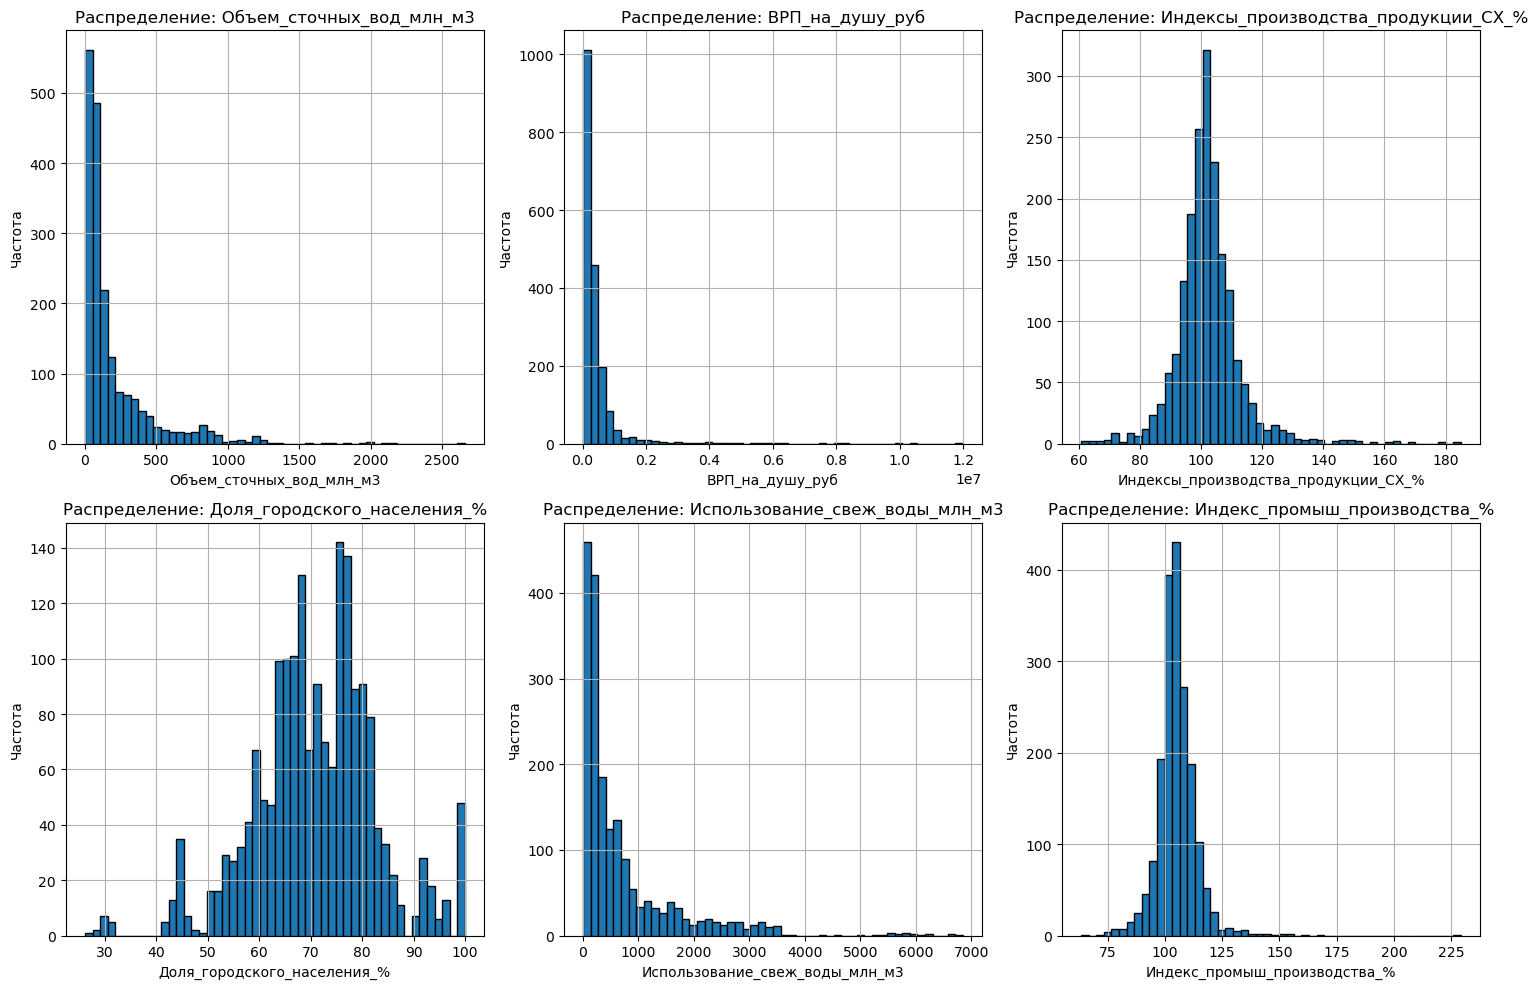

In [46]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features = ['Объем_сточных_вод_млн_м3', 'ВРП_на_душу_руб', 'Индексы_производства_продукции_СХ_%', 
            'Доля_городского_населения_%', 'Использование_свеж_воды_млн_м3', 'Индекс_промыш_производства_%']

for ax, feature in zip(axes.flatten(), features):
    df[feature].hist(bins=50, ax=ax, edgecolor='black')
    ax.set_title(f'Распределение: {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Частота')
plt.tight_layout()
plt.show()

**1. Объём сточных вод (V_сточ_вод_млн_м3)**  

Ярко выраженное правостороннее асимметричное распределение с длинным хвостом  
Большинство наблюдений концентрируется в диапазоне 0-500 млн м^3    
Присутствуют выбросы

**2. Коэффициент смертности населения (Коэф_смерт_насел)**  

Близко к нормальному распределению с центром около 14-15%    
Диапазон: 3-25%    
Относительно симметричное распределение  

**3. Численность населения (Числ_насел)**  

Правостороннее асимметричное распределение  
Большинство регионов с населением менее 2000 тыс. человек  

**4. Оборот воды (Оборот_вод_млн_м3)**  

Экстремально асимметричное распределение  
Большинство значений близки к нулю  
Есть явные выбросы

Интерпретация: повторное использование воды характерно только для крупных промышленных регионов  

**5. Нормализованные инвестиции в ООС (Инвест_в_ООС_норм)**  

Сильно правостороннее распределение  
Большинство значений в диапазоне 0-20  

### Подготовка данных

In [68]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler


# базовые признаки
features1 = [
    "Инвестиции_норм_%",
    # "Год",
]

features2 = [
    "Инвестиции_норм_%",
    "Индекс_промыш_производства_%",
    "Индексы_производства_продукции_СХ_%",
    "Доля_городского_населения_%",
    "Числ_насел",
    "Использование_свеж_воды_млн_м3",
    # "Год",
]

target = "Объем_сточных_вод_млн_м3"


X = df[features2].copy()
y = df[target].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [69]:
# LinearRegression и Ridge
from sklearn.linear_model import LinearRegression, Ridge

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lin = LinearRegression()
lin.fit(X_train_scaled, y_train)
y_pred_lin = lin.predict(X_test_scaled)

ridge = Ridge(alpha=10.0, random_state=42)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

def print_scores(name, y_true, y_pred):
    print(name)
    print("  R2:", round(r2_score(y_true, y_pred), 3))
    print("  MAE:", round(mean_absolute_error(y_true, y_pred), 1))

print_scores("LinearRegression", y_test, y_pred_lin)
print_scores("Ridge", y_test, y_pred_ridge)

LinearRegression
  R2: 0.643
  MAE: 104.1
Ridge
  R2: 0.643
  MAE: 104.1


In [70]:
# RandomForest и GradientBoosting
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=3,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print_scores("RandomForest", y_test, y_pred_rf)

gbr = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)
print_scores("GradientBoosting", y_test, y_pred_gbr)

RandomForest
  R2: 0.948
  MAE: 35.0
GradientBoosting
  R2: 0.924
  MAE: 45.8


In [71]:
def print_importances(model, X, name):
    imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
    print(f"\n{name}: важность признаков")
    for feature, value in imp.items():
        print(f"{feature:35s} {value:.4f}")
    return imp

imp_rf = print_importances(rf, X_train, "RandomForest")
imp_gbr = print_importances(gbr, X_train, "GradientBoosting")



RandomForest: важность признаков
Числ_насел                          0.6529
Использование_свеж_воды_млн_м3      0.1951
Доля_городского_населения_%         0.1144
Инвестиции_норм_%                   0.0235
Индекс_промыш_производства_%        0.0085
Индексы_производства_продукции_СХ_% 0.0056

GradientBoosting: важность признаков
Числ_насел                          0.6564
Использование_свеж_воды_млн_м3      0.1820
Доля_городского_населения_%         0.1473
Инвестиции_норм_%                   0.0098
Индексы_производства_продукции_СХ_% 0.0023
Индекс_промыш_производства_%        0.0022


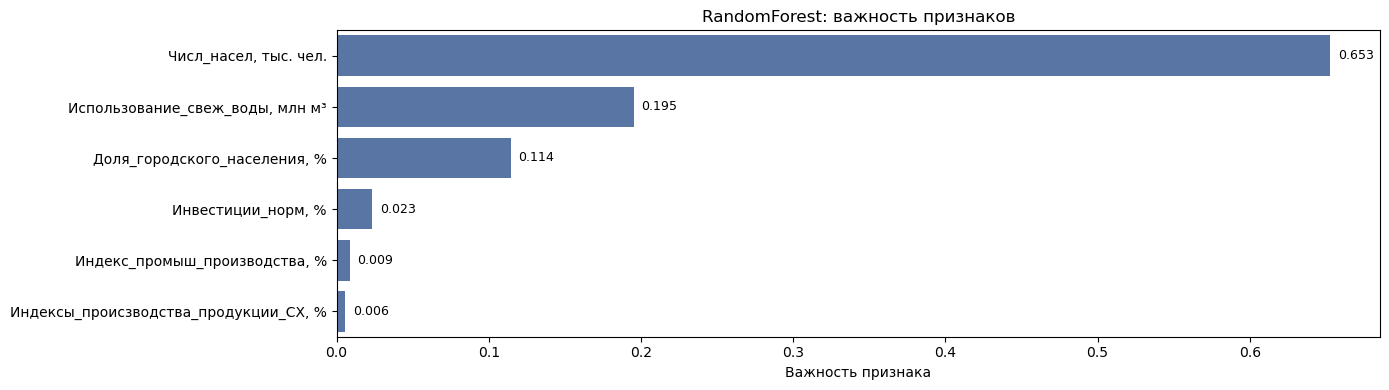

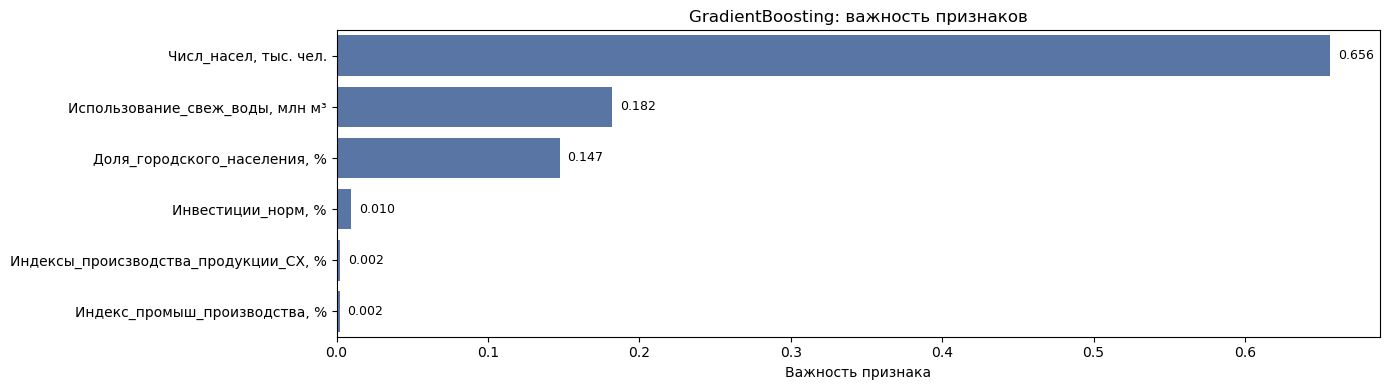

Числ_насел, тыс. чел.                    0.656424
Использование_свеж_воды, млн м³          0.181993
Доля_городского_населения, %             0.147262
Инвестиции_норм, %                       0.009780
Индексы_происзводства_продукции_СХ, %    0.002334
Индекс_промыш_производства, %            0.002207
dtype: float64

In [75]:
def plot_importances(model, X, title):
    imp = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
    plt.figure(figsize=(14, 4))
    ax = sns.barplot(x=imp.values, y=imp.index, color="#4C72B0")

    for i, v in enumerate(imp.values):
        ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=9)

    plt.xlabel("Важность признака")
    plt.ylabel("")
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return imp

X_train_renamed = X_train.copy()

X_train_renamed = X_train_renamed.rename(columns={
    "Числ_насел": "Числ_насел, тыс. чел.",
    "Использование_свеж_воды_млн_м3": "Использование_свеж_воды, млн м³",
    "Доля_городского_населения_%": "Доля_городского_населения, %",
    "Инвестиции_норм_%": "Инвестиции_норм, %",
    "Индекс_промыш_производства_%": "Индекс_промыш_производства, %",
    "Индексы_производства_продукции_СХ_%": "Индексы_происзводства_продукции_СХ, %"
})


plot_importances(rf, X_train_renamed, "RandomForest: важность признаков")
plot_importances(gbr, X_train_renamed, "GradientBoosting: важность признаков")
